1) Importamos librerías

In [1]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 
import pandas as pd

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

from tslearn.datasets import UCR_UEA_datasets
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import RepeatedStratifiedKFold
from tqdm import tqdm
from persim import PersistenceImager, PersLandscapeApprox

2) Definimos funciones

In [2]:

def load_twolead_ecg():
    """
    Loads TwoLeadECG dataset from UCR archive.
    Returns:
        X: signals (n_samples, time_length)
        y: labels (binary)
    """
    ucr = UCR_UEA_datasets()
    X_train, y_train, X_test, y_test = ucr.load_dataset("TwoLeadECG")
    print(X_train.shape)
    print(X_test.shape)

    return X_train, y_train, X_test, y_test


def signal_to_curve(signal):
    """
    Converts 1D time series into 2D curve safely.
    """
    signal = np.array(signal).astype(float).squeeze()  # 🔴 clave

    t = np.arange(len(signal)).astype(float)

    # normalize
    x = (t - np.min(t)) / (np.max(t) - np.min(t) + 1e-8)
    y = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    return x, y


def build_dataset_from_ecg(X_raw, y_raw, layer, n_points=400):
    """
    Builds PET dataset from TwoLeadECG.
    """

    X_pet = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        # convert signal to geometric curve
        x, y = signal_to_curve(signal)

        # resample to fixed number of points (important for PET stability)
        idx = np.linspace(0, len(x) - 1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pet, _ = compute_pet_from_shape(x, y, layer)

        X_pet.append(pet)
        y_labels.append(int(label))

    return np.array(X_pet), np.array(y_labels)

def compute_global_pe(y, layer):
    """
    Global persistent entropy (single filtration).
    """
    y_tf = tf.constant(y, dtype=tf.float32)

    dgms = layer.call(y_tf)
    dgm = dgms[0][0]

    return persistent_entropy(dgm)

def build_dataset_pe_from_ecg(X_raw, y_raw, layer, n_points):
    """
    Builds Persistent Entropy (single feature) dataset.
    """

    X_pe = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(0, len(x)-1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pe = compute_global_pe(x, layer)

        X_pe.append([pe])      # shape = (1,)
        y_labels.append(int(label))

    return np.array(X_pe), np.array(y_labels)

def compute_persistence_diagram(y, layer):

    y_tf = tf.constant(y, dtype=tf.float32)

    dgms = layer.call(y_tf)

    dgm = dgms[0][0].numpy()

    dgm = dgm[np.isfinite(dgm[:,1])]

    return dgm

pimgr = PersistenceImager(
    pixel_size=0.05
)

def persistence_image_features(dgm):

    img = pimgr.transform(dgm)

    return img.flatten()

def build_dataset_pi(X_raw, y_raw, layer, n_points):

    X_pi = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(
            0,
            len(x)-1,
            n_points
        ).astype(int)

        y = y[idx]

        dgm = compute_persistence_diagram(
            y,
            layer
        )

        feat = persistence_image_features(dgm)

        X_pi.append(feat)
        y_labels.append(int(label))

    return np.array(X_pi), np.array(y_labels)

def persistence_landscape_features(
        dgm,
        n_bins=100,
        k_max=5):

    if len(dgm) == 0:
        return np.zeros(k_max*n_bins)

    births = dgm[:,0]
    deaths = dgm[:,1]

    grid = np.linspace(
        births.min(),
        deaths.max(),
        n_bins
    )

    landscapes = []

    for t in grid:

        vals = []

        for b,d in zip(births,deaths):

            val = max(
                0,
                min(t-b,d-t)
            )

            vals.append(val)

        vals = sorted(vals, reverse=True)

        for k in range(k_max):

            if k < len(vals):
                landscapes.append(vals[k])
            else:
                landscapes.append(0)

    return np.array(landscapes)

def betti_curve_features(
        dgm,
        n_bins=100):

    births = dgm[:,0]
    deaths = dgm[:,1]

    tmin = births.min()
    tmax = deaths.max()

    grid = np.linspace(
        tmin,
        tmax,
        n_bins
    )

    curve = []

    for t in grid:

        betti = np.sum(
            (births <= t) &
            (deaths > t)
        )

        curve.append(betti)

    return np.array(curve)

def build_dataset_descriptor(
        X_raw,
        y_raw,
        layer,
        n_points,
        descriptor):

    X_out = []
    y_out = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(
            0,
            len(x)-1,
            n_points
        ).astype(int)

        y = y[idx]

        feat = descriptor(y, layer)

        X_out.append(feat)

        y_out.append(int(label))

    return np.array(X_out), np.array(y_out)

def descriptor_pe(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    if len(dgm) == 0:
        return np.array([0.0])

    pe = persistent_entropy(dgm)

    return np.array([pe])


def descriptor_pi(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    return persistence_image_features(dgm)


def descriptor_bc(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    return betti_curve_features(dgm)


def descriptor_pl(y, layer):

    dgm = compute_persistence_diagram(
        y,
        layer
    )

    return persistence_landscape_features(dgm)

def descriptor_pet(signal, layer):

    x, y = signal_to_curve(signal)

    pet, _ = compute_pet_from_shape(
        x,
        y,
        layer
    )

    return pet

def build_dataset_pet(
        X_raw,
        y_raw,
        layer,
        n_points):

    X_pet = []
    y_pet = []

    for signal, label in zip(X_raw, y_raw):

        x, y = signal_to_curve(signal)

        idx = np.linspace(
            0,
            len(x)-1,
            n_points
        ).astype(int)

        x = x[idx]
        y = y[idx]

        pet,_ = compute_pet_from_shape(
            x,
            y,
            layer
        )

        X_pet.append(pet)

        y_pet.append(int(label))

    return np.array(X_pet), np.array(y_pet)

def experiment_ecg(
        X_train,
        X_test,
        y_train,
        y_test,
        layer,
        n_points):

    print("\n========================")
    print("Topological Comparison")
    print("========================")

    # RAW

    X_tr_raw = np.squeeze(X_train)
    X_ts_raw = np.squeeze(X_test)

    # PE

    X_tr_pe,_ = build_dataset_descriptor(
        X_train,
        y_train,
        layer,
        n_points,
        descriptor_pe
    )

    X_ts_pe,_ = build_dataset_descriptor(
        X_test,
        y_test,
        layer,
        n_points,
        descriptor_pe
    )

    # PI

    X_tr_pi,_ = build_dataset_descriptor(
        X_train,
        y_train,
        layer,
        n_points,
        descriptor_pi
    )

    X_ts_pi,_ = build_dataset_descriptor(
        X_test,
        y_test,
        layer,
        n_points,
        descriptor_pi
    )

    # BC

    X_tr_bc,_ = build_dataset_descriptor(
        X_train,
        y_train,
        layer,
        n_points,
        descriptor_bc
    )

    X_ts_bc,_ = build_dataset_descriptor(
        X_test,
        y_test,
        layer,
        n_points,
        descriptor_bc
    )

    # PL

    X_tr_pl,_ = build_dataset_descriptor(
        X_train,
        y_train,
        layer,
        n_points,
        descriptor_pl
    )

    X_ts_pl,_ = build_dataset_descriptor(
        X_test,
        y_test,
        layer,
        n_points,
        descriptor_pl
    )

    # PET

    X_tr_pet,_ = build_dataset_pet(
        X_train,
        y_train,
        layer,
        n_points
    )

    X_ts_pet,_ = build_dataset_pet(
        X_test,
        y_test,
        layer,
        n_points
    )

    datasets = {

        "Raw":
            (X_tr_raw, X_ts_raw),

        "PE":
            (X_tr_pe, X_ts_pe),

        "Betti Curve":
            (X_tr_bc, X_ts_bc),

        "Persistence Landscape":
            (X_tr_pl, X_ts_pl),

        "Persistence Image":
            (X_tr_pi, X_ts_pi),

        "PET":
            (X_tr_pet, X_ts_pet)
    }

    models = {

        "SVM":
            SVC(
                kernel="linear",
                probability=True,
                random_state=42
            ),

        "Random Forest":
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            ),

        "XGBoost":
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            )
    }

    results = []

    for representation,(Xtr,Xts) in datasets.items():

        print("\n")
        print("="*70)
        print(representation)
        print(Xtr.shape)
        print("="*70)

        for model_name,clf in models.items():

            clf.fit(
                Xtr,
                y_train
            )

            pred = clf.predict(Xts)

            if hasattr(clf,"predict_proba"):
                prob = clf.predict_proba(Xts)[:,1]
            else:
                prob = clf.decision_function(Xts)

            acc = accuracy_score(
                y_test,
                pred
            )

            bal_acc = balanced_accuracy_score(
                y_test,
                pred
            )

            f1 = f1_score(
                y_test,
                pred
            )

            auc = roc_auc_score(
                y_test,
                prob
            )

            results.append({

                "Representation":
                    representation,

                "Dimension":
                    Xtr.shape[1],

                "Model":
                    model_name,

                "Accuracy":
                    acc,

                "Balanced Accuracy":
                    bal_acc,

                "F1":
                    f1,

                "AUC":
                    auc
            })

            print(
                f"{model_name:15s} "
                f"ACC={acc:.4f} "
                f"BAL={bal_acc:.4f} "
                f"F1={f1:.4f} "
                f"AUC={auc:.4f}"
            )

    results = pd.DataFrame(results)

    print("\nSUMMARY")
    print(results)

    return results

def plot_two_signals(X, y):
    """
    Plots one example per class from TwoLeadECG.
    """

    X = np.array(X)
    y = np.array(y)

    # find one sample per class
    idx_class_0 = np.where(y == 1)[0]
    idx_class_1 = np.where(y == 2)[0]

    sig0 = np.squeeze(X[idx_class_0])
    sig1 = np.squeeze(X[idx_class_1])

    t0 = np.arange(len(sig0))
    t1 = np.arange(len(sig1))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(t0, sig0)
    plt.title("TwoLeadECG - Class 1")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.plot(t1, sig1)
    plt.title("TwoLeadECG - Class 2")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles

3) Vemos el dataset

In [3]:
X_train, y_train, X_test, y_test = load_twolead_ecg()
# Convert labels to 0/1 for compatibility with XGBoost
y_train = np.where(y_train == np.min(y_train), 0, 1)
y_test = np.where(y_test == np.min(y_test), 0, 1)


X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

dict(zip(unique, counts))


(23, 82, 1)
(1139, 82, 1)
(1162, 82, 1)
(1162,)


{np.int64(0): np.int64(581), np.int64(1): np.int64(581)}

1162 señales de longitud 82, con una muestra balanceada: 581 ecg clasificadas en tipo 1 y 581 clasificadas en tipo 2. Tipo 1 es latidos con patron normal, tipo 2 es latido con morfologia istinta.

4) Visualizamos señales de ambos tipos

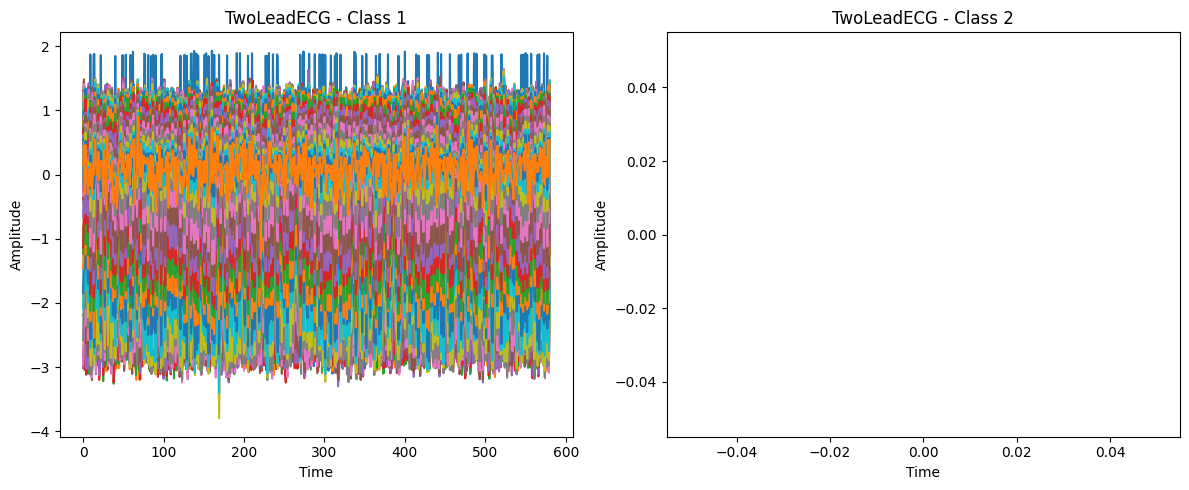

In [31]:
plot_two_signals(X,y)

5) Run SVM using PET as input data

In [4]:
n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_ecg(X_train, X_test, y_train,y_test, layer, n_points=n_points)


Topological Comparison


Raw
(23, 82)
SVM             ACC=0.9421 BAL=0.9421 F1=0.9420 AUC=0.9785
Random Forest   ACC=0.7191 BAL=0.7192 F1=0.6728 AUC=0.8424
XGBoost         ACC=0.7814 BAL=0.7814 F1=0.7688 AUC=0.8671


PE
(23, 1)
SVM             ACC=0.4996 BAL=0.5000 F1=0.0000 AUC=0.2127
Random Forest   ACC=0.6629 BAL=0.6629 F1=0.6391 AUC=0.7194
XGBoost         ACC=0.6910 BAL=0.6910 F1=0.6857 AUC=0.7465


Betti Curve
(23, 100)
SVM             ACC=0.7823 BAL=0.7823 F1=0.7669 AUC=0.8763
Random Forest   ACC=0.8727 BAL=0.8727 F1=0.8713 AUC=0.9442
XGBoost         ACC=0.7867 BAL=0.7867 F1=0.7625 AUC=0.8695


Persistence Landscape
(23, 500)
SVM             ACC=0.4996 BAL=0.5000 F1=0.0000 AUC=0.1527
Random Forest   ACC=0.8946 BAL=0.8946 F1=0.8992 AUC=0.9622
XGBoost         ACC=0.8358 BAL=0.8359 F1=0.8298 AUC=0.9044


Persistence Image
(23, 400)
SVM             ACC=0.4996 BAL=0.5000 F1=0.0000 AUC=0.0741
Random Forest   ACC=0.8543 BAL=0.8542 F1=0.8591 AUC=0.9101
XGBoost         ACC=0.8525 BAL=0.8

,Representation,Dimension,Model,Accuracy,Balanced Accuracy,F1,AUC
0,Raw,82,SVM,0.942054,0.942056,0.942004,0.978479
1,Raw,82,Random Forest,0.719052,0.719176,0.672802,0.842411
2,Raw,82,XGBoost,0.781387,0.781436,0.768802,0.867100
3,PE,1,SVM,0.499561,0.500000,0.000000,0.212737
4,PE,1,Random Forest,0.662862,0.662920,0.639098,0.719428
5,PE,1,XGBoost,0.690957,0.690972,0.685714,0.746522
6,Betti Curve,100,SVM,0.782265,0.782324,0.766917,0.876268
7,Betti Curve,100,Random Forest,0.872695,0.872705,0.871340,0.944153
8,Betti Curve,100,XGBoost,0.786655,0.786745,0.762463,0.869550
9,Persistence Landscape,500,SVM,0.499561,0.500000,0.000000,0.152662
